# Notebook 01

In [66]:
# =========================
# 01_eda_lesions.ipynb — Célula 01
# Setup + imports + seed
# =========================

from __future__ import annotations

import os
import re
import json
import csv
import math
import time
import random
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Optional, Tuple

# Dependências principais (checagem amigável)
missing = []
try:
    import numpy as np
except Exception:
    missing.append("numpy")
try:
    import pandas as pd
except Exception:
    missing.append("pandas")
try:
    from PIL import Image
except Exception:
    missing.append("Pillow")
try:
    import matplotlib.pyplot as plt
except Exception:
    missing.append("matplotlib")

if missing:
    raise RuntimeError(
        "Dependências ausentes: "
        + ", ".join(missing)
        + "\n\nInstale com:\n"
        + "  pip install " + " ".join(missing) + "\n"
        + "ou (recomendado) instale via requirements do projeto."
    )

# Reprodutibilidade mínima
REPRO_SEED = 42
random.seed(REPRO_SEED)
np.random.seed(REPRO_SEED)
os.environ["PYTHONHASHSEED"] = str(REPRO_SEED)

print("OK — imports carregados.")
print("Seed fixa:", REPRO_SEED)


OK — imports carregados.
Seed fixa: 42


In [67]:
# =========================
# 01_eda_lesions.ipynb — Célula 02
# PROJECT_ROOT + paths oficiais
# =========================

def find_project_root(start: Path, required_rel: str = "data/raw/lesions/GroundTruth.csv", max_up: int = 10) -> Path:
    """
    Sobe diretórios a partir de `start` até encontrar o arquivo required_rel.
    """
    start = start.resolve()
    cur = start
    for _ in range(max_up + 1):
        if (cur / required_rel).exists():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    raise FileNotFoundError(
        f"Não foi possível encontrar PROJECT_ROOT contendo '{required_rel}' a partir de: {start}"
    )

PROJECT_ROOT = find_project_root(Path.cwd())
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "lesions"
IMAGES_DIR = RAW_DIR / "images"
MASKS_DIR = RAW_DIR / "masks"
GT_CSV = RAW_DIR / "GroundTruth.csv"

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"

# Garantir pastas de saída
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("IMAGES_DIR  :", IMAGES_DIR)
print("MASKS_DIR   :", MASKS_DIR)
print("GT_CSV      :", GT_CSV)
print("PROCESSED   :", PROCESSED_DIR)

# Gate mínimo (Semana 0 / Semana 1)
assert IMAGES_DIR.exists(), f"IMAGES_DIR não existe: {IMAGES_DIR}"
assert GT_CSV.exists(), f"GroundTruth.csv não existe: {GT_CSV}"
# Máscaras podem ser opcionais, mas se a pasta existir, a auditoria vai considerar
if not MASKS_DIR.exists():
    print("AVISO: MASKS_DIR não existe (ok se segmentação for opcional).")
else:
    print("OK: MASKS_DIR existe.")


PROJECT_ROOT: C:\Users\win\Documents\GitHub\pimple
IMAGES_DIR  : C:\Users\win\Documents\GitHub\pimple\data\raw\lesions\images
MASKS_DIR   : C:\Users\win\Documents\GitHub\pimple\data\raw\lesions\masks
GT_CSV      : C:\Users\win\Documents\GitHub\pimple\data\raw\lesions\GroundTruth.csv
PROCESSED   : C:\Users\win\Documents\GitHub\pimple\data\processed
OK: MASKS_DIR existe.


In [68]:
# =========================
# 01_eda_lesions.ipynb — Célula 03
# Leitura do CSV + normalização
# =========================

def sniff_csv_sep(path: Path, default: str = ",") -> str:
    """
    Tenta inferir delimitador (',' ou ';' etc.) lendo um trecho do arquivo.
    """
    try:
        sample = path.read_text(encoding="utf-8", errors="ignore")[:4096]
        dialect = csv.Sniffer().sniff(sample, delimiters=[",", ";", "\t", "|"])
        return dialect.delimiter
    except Exception:
        return default

def normalize_colname(c: str) -> str:
    c = c.strip().lower()
    c = re.sub(r"\s+", "_", c)
    c = re.sub(r"[^a-z0-9_]+", "", c)
    c = re.sub(r"_+", "_", c).strip("_")
    return c

sep = sniff_csv_sep(GT_CSV, default=",")
df_raw = pd.read_csv(GT_CSV, sep=sep, low_memory=False)

df = df_raw.copy()
df.columns = [normalize_colname(c) for c in df.columns]

print("CSV lido com sep =", repr(sep))
print("df.shape:", df.shape)
display(df.head(5))

print("\ninfo():")
display(df.info())

# Visão rápida de missingness por coluna
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct.to_frame("missing_%").head(25))


CSV lido com sep = ','
df.shape: (10015, 8)


,image,mel,nv,bcc,akiec,bkl,df,vasc
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0024309,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0024310,1.0,0.0,0.0,0.0,0.0,0.0,0.0



info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   image   10015 non-null  object 
 1   mel     10015 non-null  float64
 2   nv      10015 non-null  float64
 3   bcc     10015 non-null  float64
 4   akiec   10015 non-null  float64
 5   bkl     10015 non-null  float64
 6   df      10015 non-null  float64
 7   vasc    10015 non-null  float64
dtypes: float64(7), object(1)
memory usage: 626.1+ KB


None

,missing_%
image,0.0
mel,0.0
nv,0.0
bcc,0.0
akiec,0.0
bkl,0.0
df,0.0
vasc,0.0


In [69]:
# =========================
# 01_eda_lesions.ipynb — Célula 04
# Inferência de schema (sem suposição + rastreável)
# =========================

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
MASK_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

def looks_like_filename(x: object, exts: set[str]) -> bool:
    if not isinstance(x, str):
        return False
    x = x.strip()
    if len(x) < 3:
        return False
    p = Path(x)
    return p.suffix.lower() in exts

def col_filename_score(series: pd.Series, exts: set[str]) -> float:
    s = series.dropna()
    if len(s) == 0:
        return 0.0
    return float(s.astype(str).map(lambda v: looks_like_filename(v, exts=exts)).mean())

def detect_image_col_by_filename(df: pd.DataFrame) -> Tuple[Optional[str], List[Tuple[str, float]]]:
    scores = []
    for c in df.columns:
        sc = col_filename_score(df[c], IMG_EXTS)
        if sc > 0:
            scores.append((c, sc))
    scores.sort(key=lambda x: x[1], reverse=True)
    best = scores[0][0] if scores else None
    return best, scores[:10]

def detect_mask_col_by_filename(df: pd.DataFrame) -> Tuple[Optional[str], List[Tuple[str, float]]]:
    scores = []
    for c in df.columns:
        sc = col_filename_score(df[c], MASK_EXTS)
        name_bonus = 0.15 if ("mask" in c or "seg" in c) else 0.0
        sc2 = min(1.0, sc + name_bonus)
        if sc2 > 0:
            scores.append((c, float(sc2)))
    scores.sort(key=lambda x: x[1], reverse=True)
    best = scores[0][0] if scores else None
    return best, scores[:10]

def is_binary_like(series: pd.Series) -> bool:
    s = series.dropna()
    if len(s) == 0:
        return False
    v = pd.to_numeric(s, errors="coerce").dropna()
    if len(v) == 0:
        return False
    uniq = set(v.unique().tolist())
    return uniq.issubset({0, 1})

# 1) tenta achar colunas de arquivo por extensão (pode falhar no seu caso e tudo bem)
image_col, image_candidates = detect_image_col_by_filename(df)
mask_col, mask_candidates = detect_mask_col_by_filename(df)

# 2) candidatos a labels binárias (0/1)
exclude_base = set()
if image_col:
    exclude_base.add(image_col)
if mask_col:
    exclude_base.add(mask_col)

binary_cols = [c for c in df.columns if c not in exclude_base and is_binary_like(df[c])]

# 3) detectar one-hot multi-classe vs multi-label
mode = "unknown"
target_encoding = None
label_cols: List[str] = []

if len(binary_cols) >= 2:
    X = df[binary_cols].apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)
    row_sum = X.sum(axis=1)

    # regra: se quase todas as linhas têm soma 1 (ou 0/1) => one-hot multiclass
    ratio_eq_1 = float((row_sum == 1).mean())
    ratio_in_01 = float(row_sum.isin([0, 1]).mean())

    if ratio_eq_1 >= 0.90 and ratio_in_01 >= 0.98:
        mode = "single_label"
        target_encoding = "one_hot_multiclass"
        label_cols = binary_cols
    else:
        mode = "multi_label"
        target_encoding = "multi_label_binary_cols"
        label_cols = binary_cols

meta_cols = [c for c in df.columns if c not in set(label_cols) | exclude_base]
all_columns = list(df.columns)

schema = {
    "created_at": datetime.utcnow().isoformat() + "Z",
    "project_root": str(PROJECT_ROOT),
    "raw": {
        "raw_dir": str(RAW_DIR),
        "images_dir": str(IMAGES_DIR),
        "masks_dir": str(MASKS_DIR),
        "groundtruth_csv": str(GT_CSV),
    },
    "columns": {
        "image_col": image_col,          # pode ser None agora; será confirmado na Célula 05 via match com disco
        "mask_col": mask_col if mask_col in df.columns else None,
        "mode": mode,
        "target_encoding": target_encoding,
        "label_cols": label_cols,
        "meta_cols": meta_cols,
        "all_columns": all_columns,
    },
    "diagnostics": {
        "binary_cols_count": int(len(binary_cols)),
    },
    "candidates": {
        "image_col_top10": image_candidates,
        "mask_col_top10": mask_candidates,
    },
    "notes": {
        "image_col_rule": "Se o CSV tiver apenas stem (ex.: ISIC_...), a Célula 05 define image_col por match com o diretório images/.",
        "mode_rule": "Se colunas 0/1 somam 1 na maioria => single_label one_hot_multiclass; caso contrário => multi_label.",
    },
}

print("=== SCHEMA INFERIDO (pré-disco) ===")
print("image_col (por extensão; pode ser None):", schema["columns"]["image_col"])
print("mask_col:", schema["columns"]["mask_col"])
print("mode:", schema["columns"]["mode"])
print("target_encoding:", schema["columns"]["target_encoding"])
print("label_cols_count:", len(schema["columns"]["label_cols"]))


=== SCHEMA INFERIDO (pré-disco) ===
image_col (por extensão; pode ser None): None
mask_col: None
mode: single_label
target_encoding: one_hot_multiclass
label_cols_count: 7


In [ ]:
# =========================
# 01_eda_lesions.ipynb — Célula 05
# Index de arquivos no disco + resolução por stem (resolvers oficiais)
# =========================

# Extensões (reuso — mas garante que existem)
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
MASK_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

# Sufixos comuns para máscaras — inclui o padrão real do dataset: _segmentation
MASK_SUFFIXES = [
    "", "_mask", "-mask", "_seg", "-seg",
    "_segmentation", "-segmentation",
    "_lesion", "_lesion_mask", "_binary", "_annotation", "_ann"
]

def list_files_by_ext(root: Path, exts: set[str]) -> List[Path]:
    if not root.exists():
        return []
    out: List[Path] = []
    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in exts:
            out.append(p)
    return out

def build_stem_index(files: List[Path]) -> Dict[str, List[Path]]:
    idx: Dict[str, List[Path]] = {}
    for p in files:
        stem = p.stem.strip().lower()
        idx.setdefault(stem, []).append(p)
    return idx

def safe_str(x: object) -> str:
    return "" if pd.isna(x) else str(x)

def norm_to_stem(v: str) -> str:
    """
    Normaliza valor do CSV para stem:
    - se vier 'ISIC_0001.jpg' => 'isic_0001'
    - se vier 'images/ISIC_0001.jpg' => 'isic_0001'
    - se vier 'ISIC_0001' => 'isic_0001'
    """
    v = (v or "").strip()
    if not v:
        return ""
    p = Path(v)
    name = p.name  # remove diretórios
    p2 = Path(name)
    if p2.suffix.lower() in (IMG_EXTS | MASK_EXTS):
        return p2.stem.strip().lower()
    return name.strip().lower()

# 1) Criar índice do disco (ANTES de qualquer inferência)
image_files = list_files_by_ext(IMAGES_DIR, IMG_EXTS)
mask_files = list_files_by_ext(MASKS_DIR, MASK_EXTS)

images_by_stem = build_stem_index(image_files)
masks_by_stem = build_stem_index(mask_files)

print("=== Index do disco ===")
print("IMAGES_DIR:", IMAGES_DIR)
print("MASKS_DIR :", MASKS_DIR)
print("image_files:", len(image_files))
print("mask_files :", len(mask_files))

# 2) Inferir/confirmar image_col por match de stems com disco
def infer_image_col_by_disk_stems(df: pd.DataFrame, disk_stems: set[str], max_n: int = 7000) -> Tuple[str, float, pd.DataFrame]:
    def score(series: pd.Series) -> float:
        s = series.dropna().astype(str).map(lambda x: x.strip())
        if len(s) == 0:
            return 0.0
        if len(s) > max_n:
            s = s.sample(max_n, random_state=REPRO_SEED)
        stems = s.map(norm_to_stem)
        return float(stems.isin(disk_stems).mean())

    rows = []
    for c in df.columns:
        sc = score(df[c])
        if sc > 0:
            rows.append((c, sc, int(df[c].nunique()), float(df[c].isna().mean())))
    rows.sort(key=lambda x: x[1], reverse=True)

    scores_df = pd.DataFrame(rows, columns=["col", "stem_match_ratio", "nunique", "missing_ratio"])
    if len(rows) == 0:
        raise RuntimeError("Não encontrei nenhuma coluna no CSV que bata com stems do diretório images/.")
    best_col, best_score, *_ = rows[0]
    return best_col, float(best_score), scores_df

disk_stems = set(images_by_stem.keys())
best_col, best_score, scores_df = infer_image_col_by_disk_stems(df, disk_stems)

display(scores_df.head(20))

if best_score < 0.20:
    raise RuntimeError(
        f"Match com stems do disco muito baixo ({best_score:.3f}).\n"
        "Verifique IMAGES_DIR e o conteúdo da coluna de imagem no CSV."
    )

schema["columns"]["image_col"] = best_col
schema.setdefault("diagnostics", {})
schema["diagnostics"]["image_col_stem_match_ratio"] = best_score
schema["diagnostics"]["image_col_stem_match_top20"] = scores_df.head(20).to_dict(orient="records")

print(f"image_col confirmado por match com disco: {best_col} (match_ratio={best_score:.3f})")

# 3) Resolvers oficiais usados pelo resto do notebook
def resolve_image_path(value_or_stem: str) -> Optional[Path]:
    v = (value_or_stem or "").strip()
    if not v:
        return None
    p = Path(v)

    # absoluto com extensão
    if p.is_absolute() and p.exists() and p.suffix.lower() in IMG_EXTS:
        return p

    # com extensão (talvez veio "images/xxx.jpg")
    if p.suffix.lower() in IMG_EXTS:
        cand = IMAGES_DIR / p.name
        if cand.exists():
            return cand
        st = p.stem.strip().lower()
        lst = images_by_stem.get(st, [])
        return sorted(lst)[0] if lst else None

    # sem extensão => stem
    st = norm_to_stem(v)
    lst = images_by_stem.get(st, [])
    return sorted(lst)[0] if lst else None

def resolve_mask_path_from_csv(value: str) -> Optional[Path]:
    v = (value or "").strip()
    if not v:
        return None
    p = Path(v)

    if p.is_absolute() and p.exists() and p.suffix.lower() in MASK_EXTS:
        return p

    if p.suffix.lower() in MASK_EXTS:
        cand = MASKS_DIR / p.name
        if cand.exists():
            return cand
        st = p.stem.strip().lower()
        lst = masks_by_stem.get(st, [])
        return sorted(lst)[0] if lst else None

    return None

def resolve_mask_path_by_stem(stem: str) -> Optional[Path]:
    s = (stem or "").strip().lower()
    if not s:
        return None

    # direta
    if s in masks_by_stem:
        return sorted(masks_by_stem[s])[0]

    # sufixos
    for suf in MASK_SUFFIXES:
        key = (s + suf).strip().lower()
        if key in masks_by_stem:
            return sorted(masks_by_stem[key])[0]

    # se o stem já veio com sufixo, tenta remover
    for suf in MASK_SUFFIXES:
        if suf and s.endswith(suf):
            base = s[: -len(suf)]
            if base in masks_by_stem:
                return sorted(masks_by_stem[base])[0]

    return None

print("Resolvers criados: resolve_image_path, resolve_mask_path_from_csv, resolve_mask_path_by_stem")

# --- Recalcular meta_cols após confirmar image_col (evita distorção na EDA) ---
final_image_col = schema["columns"]["image_col"]
final_mask_col = schema["columns"].get("mask_col")

label_cols = schema["columns"].get("label_cols", []) or []

exclude = set(label_cols)
if final_image_col:
    exclude.add(final_image_col)
if final_mask_col:
    exclude.add(final_mask_col)

schema["columns"]["meta_cols"] = [c for c in df.columns if c not in exclude]

print("meta_cols atualizado. meta_cols_count =", len(schema["columns"]["meta_cols"]))



=== Index do disco ===
IMAGES_DIR: C:\Users\win\Documents\GitHub\pimple\data\raw\lesions\images
MASKS_DIR : C:\Users\win\Documents\GitHub\pimple\data\raw\lesions\masks
image_files: 10015
mask_files : 10015


,col,stem_match_ratio,nunique,missing_ratio
0,image,1.0,10015,0.0


image_col confirmado por match com disco: image (match_ratio=1.000)
Resolvers criados: resolve_image_path, resolve_mask_path_from_csv, resolve_mask_path_by_stem


In [71]:
# =========================
# 01_eda_lesions.ipynb — Célula 06
# Auditoria CSV ↔ disco (única) + checagem de duplicatas
# =========================

image_col_for_audit = schema["columns"]["image_col"]
mask_col_for_audit = schema["columns"]["mask_col"]

rows = []
for i, r in df.iterrows():
    img_val = safe_str(r.get(image_col_for_audit))
    img_stem = norm_to_stem(img_val) if img_val else ""
    img_path = resolve_image_path(img_val) if img_val else (resolve_image_path(img_stem) if img_stem else None)

    mask_val = safe_str(r.get(mask_col_for_audit)) if mask_col_for_audit else ""
    mask_path = None

    if mask_val:
        mask_path = resolve_mask_path_from_csv(mask_val)

    if mask_path is None and img_stem and MASKS_DIR.exists():
        mask_path = resolve_mask_path_by_stem(img_stem)

    issues = []
    if not img_val:
        issues.append("CSV_IMAGE_VALUE_EMPTY")
    if img_path is None or (img_path is not None and not img_path.exists()):
        issues.append("IMAGE_NOT_FOUND_ON_DISK")
    if MASKS_DIR.exists():
        if mask_path is None or (mask_path is not None and not mask_path.exists()):
            issues.append("MASK_NOT_FOUND_ON_DISK")

    rows.append({
        "row_idx": i,
        "image_col_used": image_col_for_audit,
        "csv_image_value": img_val,
        "image_stem": img_stem,
        "resolved_image_rel": str(img_path.relative_to(PROJECT_ROOT)) if img_path else "",
        "image_exists": bool(img_path and img_path.exists()),
        "mask_col_used": mask_col_for_audit or "",
        "csv_mask_value": mask_val,
        "resolved_mask_rel": str(mask_path.relative_to(PROJECT_ROOT)) if mask_path else "",
        "mask_exists": bool(mask_path and mask_path.exists()),
        "issues": "|".join(issues) if issues else "",
    })

audit_df = pd.DataFrame(rows)

print("=== Auditoria — resumo ===")
print("Total linhas CSV:", len(audit_df))
print("Imagens ausentes :", int((~audit_df["image_exists"]).sum()))
if MASKS_DIR.exists():
    print("Máscaras ausentes:", int((~audit_df["mask_exists"]).sum()))
else:
    print("Máscaras ausentes: (pasta masks não existe)")

display(audit_df.head(10)[["csv_image_value","image_stem","resolved_image_rel","image_exists","issues"]])

# Disco ↔ CSV por stem
csv_stems = set([s for s in audit_df["image_stem"].astype(str).str.lower().tolist() if s])
disk_image_stems = set(images_by_stem.keys())

disk_only_images = sorted(list(disk_image_stems - csv_stems))
csv_only_images  = sorted(list(csv_stems - disk_image_stems))

print("\n=== Disco ↔ CSV (por stem) ===")
print("Stems no disco e não no CSV:", len(disk_only_images))
print("Stems no CSV e não no disco:", len(csv_only_images))

# Duplicatas por stem (pedido no plano)
csv_dup_lines = int(audit_df["image_stem"].duplicated(keep=False).sum())
disk_dup_images = [k for k, v in images_by_stem.items() if len(v) > 1]
disk_dup_masks  = [k for k, v in masks_by_stem.items() if len(v) > 1]

print("\n=== Duplicatas por stem ===")
print("CSV (linhas envolvidas em duplicata):", csv_dup_lines)
print("Disco imagens (stems duplicados):", len(disk_dup_images))
print("Disco masks  (stems duplicados):", len(disk_dup_masks))
print("Amostra disco imagens duplicadas:", disk_dup_images[:10])
print("Amostra disco masks duplicadas  :", disk_dup_masks[:10])


=== Auditoria — resumo ===
Total linhas CSV: 10015
Imagens ausentes : 0
Máscaras ausentes: 0


,csv_image_value,image_stem,resolved_image_rel,image_exists,issues
0,ISIC_0024306,isic_0024306,data\raw\lesions\images\ISIC_0024306.jpg,True,
1,ISIC_0024307,isic_0024307,data\raw\lesions\images\ISIC_0024307.jpg,True,
2,ISIC_0024308,isic_0024308,data\raw\lesions\images\ISIC_0024308.jpg,True,
3,ISIC_0024309,isic_0024309,data\raw\lesions\images\ISIC_0024309.jpg,True,
4,ISIC_0024310,isic_0024310,data\raw\lesions\images\ISIC_0024310.jpg,True,
5,ISIC_0024311,isic_0024311,data\raw\lesions\images\ISIC_0024311.jpg,True,
6,ISIC_0024312,isic_0024312,data\raw\lesions\images\ISIC_0024312.jpg,True,
7,ISIC_0024313,isic_0024313,data\raw\lesions\images\ISIC_0024313.jpg,True,
8,ISIC_0024314,isic_0024314,data\raw\lesions\images\ISIC_0024314.jpg,True,
9,ISIC_0024315,isic_0024315,data\raw\lesions\images\ISIC_0024315.jpg,True,



=== Disco ↔ CSV (por stem) ===
Stems no disco e não no CSV: 0
Stems no CSV e não no disco: 0

=== Duplicatas por stem ===
CSV (linhas envolvidas em duplicata): 0
Disco imagens (stems duplicados): 0
Disco masks  (stems duplicados): 0
Amostra disco imagens duplicadas: []
Amostra disco masks duplicadas  : []


In [72]:
# =========================
# 01_eda_lesions.ipynb — Célula 07
# EDA estatística mínima (labels + metadados)
# =========================

mode = schema["columns"]["mode"]
target_encoding = schema["columns"].get("target_encoding")
label_cols = schema["columns"]["label_cols"]
meta_cols = schema["columns"]["meta_cols"]

print("mode:", mode)
print("target_encoding:", target_encoding)
print("label_cols:", label_cols[:20], ("..." if len(label_cols) > 20 else ""))
print("meta_cols_count:", len(meta_cols))

# Missingness (top 25)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct.to_frame("missing_%").head(25))

# Labels
if mode == "single_label" and target_encoding == "one_hot_multiclass" and len(label_cols) >= 3:
    X = df[label_cols].apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)
    row_sum = X.sum(axis=1)

    print("\nOne-hot sanity (row_sum):")
    display(row_sum.value_counts(dropna=False).head(10).to_frame("rows"))

    invalid = int((row_sum != 1).sum())
    print("Linhas inválidas (row_sum != 1):", invalid, f"({invalid/len(df)*100:.2f}%)")

    counts = X.sum(axis=0).sort_values(ascending=False)
    print("\nContagem por classe (one-hot):")
    display(counts.to_frame("count"))

elif mode == "multi_label" and len(label_cols) >= 2:
    sums = {}
    for c in label_cols:
        v = pd.to_numeric(df[c], errors="coerce")
        sums[c] = int((v == 1).sum())
    ml = pd.DataFrame({"positives": sums}).sort_values("positives", ascending=False)
    display(ml)

else:
    print("\nAviso: labels não detectadas de forma conclusiva (mode=unknown).")

# Metadados — distribuições básicas quando existirem (plano exige)
def is_numeric_series(s: pd.Series) -> bool:
    return pd.api.types.is_numeric_dtype(s) or pd.to_numeric(s.dropna(), errors="coerce").notna().mean() > 0.8

meta_preview = []
for c in meta_cols:
    c_low = c.lower()
    if any(k in c_low for k in ["age", "sexo", "sex", "gender", "anatom", "site", "location", "patient", "lesion"]):
        meta_preview.append(c)

# fallback: se não achou, pega algumas colunas meta
if len(meta_preview) == 0:
    meta_preview = meta_cols[:8]
else:
    meta_preview = meta_preview[:12]

print("\nMeta cols (amostra):", meta_preview)

for c in meta_preview:
    s = df[c]
    print(f"\n--- {c} ---")
    if is_numeric_series(s):
        s_num = pd.to_numeric(s, errors="coerce")
        display(s_num.describe())
    else:
        display(s.astype(str).value_counts(dropna=False).head(15).to_frame("count"))


mode: single_label
target_encoding: one_hot_multiclass
label_cols: ['mel', 'nv', 'bcc', 'akiec', 'bkl', 'df', 'vasc'] 
meta_cols_count: 1


,missing_%
image,0.0
mel,0.0
nv,0.0
bcc,0.0
akiec,0.0
bkl,0.0
df,0.0
vasc,0.0



One-hot sanity (row_sum):


,rows
1,10015


Linhas inválidas (row_sum != 1): 0 (0.00%)

Contagem por classe (one-hot):


,count
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115



Meta cols (amostra): ['image']

--- image ---


,count
image,
ISIC_0024306,1
ISIC_0030986,1
ISIC_0030979,1
ISIC_0030980,1
ISIC_0030981,1
ISIC_0030982,1
ISIC_0030983,1
ISIC_0030984,1
ISIC_0030985,1


Mostrando sample stem = isic_0025923


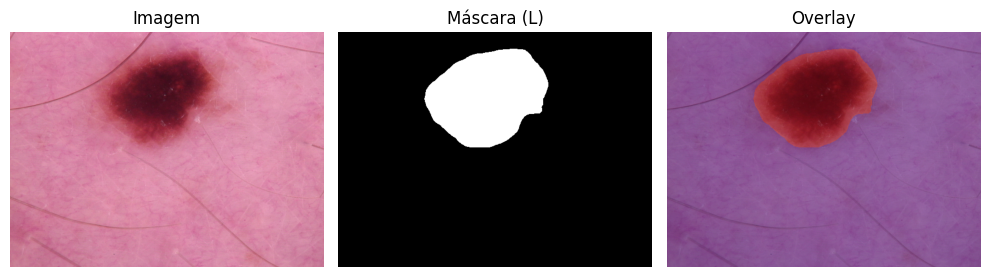

In [73]:
# =========================
# 01_eda_lesions.ipynb — Célula 08
# Visual sanity checks (wrappers oficiais do plano)
# =========================

def load_rgb(path: Path) -> np.ndarray:
    im = Image.open(path).convert("RGB")
    return np.array(im)

def load_mask_l(path: Path, target_size: Optional[Tuple[int,int]] = None) -> np.ndarray:
    m = Image.open(path).convert("L")
    if target_size is not None:
        m = m.resize((target_size[1], target_size[0]), resample=Image.NEAREST)  # (W,H)
    return np.array(m)

# Wrappers exigidos no plano
def image_path(stem_or_value: str) -> Optional[Path]:
    return resolve_image_path(stem_or_value)

def mask_path(stem_or_value: str) -> Optional[Path]:
    st = norm_to_stem(stem_or_value)
    return resolve_mask_path_by_stem(st) if MASKS_DIR.exists() else None

def show_sample(stem_or_value: str, alpha: float = 0.35):
    st = norm_to_stem(stem_or_value)

    img_p = image_path(st) or image_path(st + ".jpg") or image_path(st + ".png")
    if img_p is None:
        raise FileNotFoundError(f"Imagem não encontrada para stem={st}")

    img = load_rgb(img_p)
    m_p = mask_path(st)

    plt.figure(figsize=(10, 4))
    if m_p and m_p.exists():
        mask = load_mask_l(m_p, target_size=img.shape[:2])
        m_bin = (mask > 0).astype(np.uint8)

        plt.subplot(1, 3, 1)
        plt.title("Imagem")
        plt.imshow(img)
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.title("Máscara (L)")
        plt.imshow(mask, cmap="gray")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.title("Overlay")
        plt.imshow(img)
        plt.imshow(m_bin, alpha=alpha, cmap="jet")
        plt.axis("off")
    else:
        plt.title("Imagem (sem máscara resolvida)")
        plt.imshow(img)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Seleção robusta
valid_imgs = audit_df[audit_df["image_exists"]]
if len(valid_imgs) == 0:
    raise RuntimeError("Nenhuma imagem do CSV foi resolvida no disco. Verifique a Célula 06.")

if MASKS_DIR.exists():
    with_mask = valid_imgs[valid_imgs["mask_exists"]]
    pick_df = with_mask if len(with_mask) > 0 else valid_imgs
else:
    pick_df = valid_imgs

stem = pick_df.sample(1, random_state=REPRO_SEED)["image_stem"].iloc[0]
print("Mostrando sample stem =", stem)
show_sample(stem)


In [74]:
# =========================
# 01_eda_lesions.ipynb — Célula 09
# Salvar artefatos obrigatórios
# =========================

def to_rel(p: Path) -> str:
    try:
        return str(p.relative_to(PROJECT_ROOT))
    except Exception:
        return str(p)

# Duplicatas (contagens)
csv_dup_count = int((audit_df["image_stem"].value_counts() > 1).sum())
disk_dup_images_count = int(sum(1 for k, v in images_by_stem.items() if len(v) > 1))
disk_dup_masks_count = int(sum(1 for k, v in masks_by_stem.items() if len(v) > 1))

summary_rows = [
    ("created_at_utc", datetime.utcnow().isoformat() + "Z"),
    ("project_root", str(PROJECT_ROOT)),
    ("groundtruth_csv", to_rel(GT_CSV)),
    ("images_dir", to_rel(IMAGES_DIR)),
    ("masks_dir", to_rel(MASKS_DIR)),
    ("csv_rows", int(df.shape[0])),
    ("csv_cols", int(df.shape[1])),
    ("image_files_on_disk", int(len(image_files))),
    ("mask_files_on_disk", int(len(mask_files))),
    ("image_col_inferred", str(schema["columns"]["image_col"])),
    ("mask_col_inferred", str(schema["columns"]["mask_col"])),
    ("mode_inferred", str(schema["columns"]["mode"])),
    ("target_encoding", str(schema["columns"].get("target_encoding"))),
    ("label_cols_count", int(len(schema["columns"]["label_cols"]))),
    ("meta_cols_count", int(len(schema["columns"]["meta_cols"]))),
    ("audit_total_rows", int(len(audit_df))),
    ("audit_images_missing", int((~audit_df["image_exists"]).sum())),
    ("audit_masks_missing", int((MASKS_DIR.exists() and (~audit_df["mask_exists"]).sum()) or 0)),
    ("disk_only_image_stems", int(len(disk_only_images))),
    ("csv_only_image_stems", int(len(csv_only_images))),
    ("csv_duplicate_stems", csv_dup_count),
    ("disk_duplicate_image_stems", disk_dup_images_count),
    ("disk_duplicate_mask_stems", disk_dup_masks_count),
]

eda_resumo = pd.DataFrame(summary_rows, columns=["key", "value"])

out_schema = PROCESSED_DIR / "eda_schema_inferido.json"
out_audit = PROCESSED_DIR / "eda_auditoria_arquivos.csv"
out_resumo = PROCESSED_DIR / "eda_resumo.csv"

with out_schema.open("w", encoding="utf-8") as f:
    json.dump(schema, f, ensure_ascii=False, indent=2)

audit_df.to_csv(out_audit, index=False, encoding="utf-8")
eda_resumo.to_csv(out_resumo, index=False, encoding="utf-8")

print("OK — artefatos salvos em data/processed/")
print(" -", to_rel(out_schema))
print(" -", to_rel(out_audit))
print(" -", to_rel(out_resumo))

display(eda_resumo)


OK — artefatos salvos em data/processed/
 - data\processed\eda_schema_inferido.json
 - data\processed\eda_auditoria_arquivos.csv
 - data\processed\eda_resumo.csv


,key,value
0,created_at_utc,2026-01-22T19:49:33.758387Z
1,project_root,C:\Users\win\Documents\GitHub\pimple
2,groundtruth_csv,data\raw\lesions\GroundTruth.csv
3,images_dir,data\raw\lesions\images
4,masks_dir,data\raw\lesions\masks
5,csv_rows,10015
6,csv_cols,8
7,image_files_on_disk,10015
8,mask_files_on_disk,10015
9,image_col_inferred,image
